In [26]:
import pandas as pd

tweets = pd.read_csv(
    "Airline.csv",
    encoding="latin-1",
    on_bad_lines="skip"
)

tweets.tail()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,airline_sentiment,airline_sentiment:confidence,negativereason,negativereason:confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_id,tweet_location,user_timezone
14635,681679794,False,finalized,3,2/25/15 19:46,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2/22/15 12:01,5.695880e+17,NaN,NaN
14636,681679795,False,finalized,3,2/25/15 19:14,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2/22/15 11:59,5.695870e+17,Texas,NaN
14637,681679796,False,finalized,3,2/25/15 19:04,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2/22/15 11:59,5.695870e+17,"Nigeria,lagos",NaN
14638,681679797,False,finalized,3,2/25/15 18:59,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2/22/15 11:59,5.695870e+17,New Jersey,Eastern Time (US & Canada)
14639,681679798,False,finalized,3,2/25/15 19:06,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2/22/15 11:58,5.695870e+17,"dallas, TX",NaN


In [27]:
type(tweets['text'])

pandas.core.series.Series

In [48]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-z\s]", "", text)

    # 🔥 FIX repeated letters (aaa → aa)
    text = re.sub(r"(.)\1{1,}", r"\1", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

tweets['clean_text'] = tweets['text'].apply(clean_text)
tweets['clean_text']

,clean_text
0,what said
1,plus youve aded comercials to the experience t...
2,i didnt today must mean i ned to take another ...
3,its realy agresive to blast obnoxious entertai...
4,and its a realy big bad thing about it
...,...
14635,thank you we got on a diferent flight to chicago
14636,leaving over minutes late flight no warnings o...
14637,please bring american airlines to
14638,you have my money you change my flight and don...


In [49]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def process_text(text):
    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [w for w in words if len(w) > 2]

    return " ".join(words)

tweets["processed_text"] = tweets["clean_text"].apply(process_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [50]:
from nltk.tokenize import word_tokenize

nltk.download('punkt_tab')
tweets["tokens"] = tweets["processed_text"].apply(word_tokenize)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [54]:
from textblob import TextBlob

def get_sentiment(text):
    if not isinstance(text, str):
        return 0

    return TextBlob(text).sentiment.polarity

tweets["polarity"] = tweets["processed_text"].apply(get_sentiment)

tweets[["processed_text", "polarity"]].head()

,processed_text,polarity
0,said,0.0000
1,plus youve aded comercials experience tacky,0.0000
2,didnt today must mean ned take another trip,-0.3125
3,realy agresive blast obnoxious entertainment g...,0.0000
4,realy big bad thing,-0.3500


In [56]:
def label_sentiment(p):
    if p > 0:
        return "positive"
    elif p < 0:
        return "negative"
    return "neutral"

tweets["predicted_sentiment"] = tweets["polarity"].apply(label_sentiment)

tweets[["processed_text", "predicted_sentiment"]].head()

,processed_text,predicted_sentiment
0,said,neutral
1,plus youve aded comercials experience tacky,neutral
2,didnt today must mean ned take another trip,negative
3,realy agresive blast obnoxious entertainment g...,neutral
4,realy big bad thing,negative


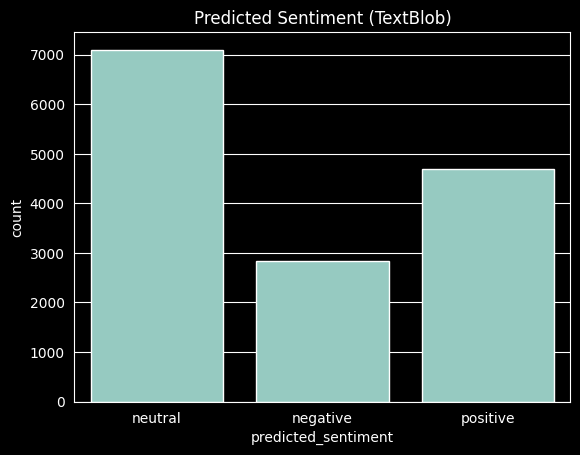

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=tweets["predicted_sentiment"])
plt.title("Predicted Sentiment (TextBlob)")
plt.show()